In [77]:
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np

In [78]:
N = 10000
radius = 5
epsilon = 0.2

In [79]:
xs = np.linspace(-radius, radius, N)
ys = np.sqrt(25 - xs**2) + np.random.normal(scale=1, size=xs.shape[0]) # with some noise in the y values

def distance(point, radius):
    x, y = point
    distance_from_origin = np.sqrt(y**2 + x**2)
    distance_from_curve = abs(distance_from_origin - radius)
    return distance_from_curve

In [80]:
samples = []

for x, y in zip(xs, ys):
    if (distance((x,y), radius) <= epsilon):
        samples.append([x, y, 1])
    else:
        samples.append([x, y, 0])

samples = np.array(samples)

positive_samples =  samples[samples[:, 2] == 1]
neg_samples = samples[samples[:, 2] == 0]
np.random.shuffle(neg_samples)
neg_samples = neg_samples[:int(len(positive_samples) * 0.2)]
train_sampels = np.concatenate((positive_samples, neg_samples))
np.random.shuffle(train_sampels)

In [81]:
train_sampels.shape

(2874, 3)

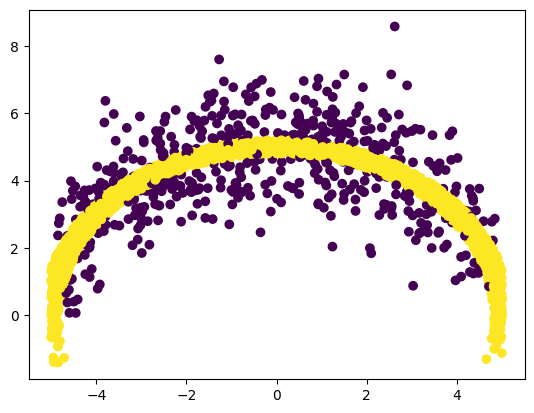

In [82]:
plt.scatter(train_sampels[:, 0], train_sampels[:, 1], c=train_sampels[:, 2])

In [83]:
from torch.utils.data import Dataset, DataLoader

In [84]:
class CircleDataset(Dataset):
    def __init__(self, inputs, labels):
        super().__init__()
        self.inputs = torch.from_numpy(inputs).float()
        self.labels = torch.from_numpy(labels).float().unsqueeze(1)
    
    def __getitem__(self, idx):
        return self.inputs[idx], self.labels[idx]
    
    def __len__(self):
        return len(self.inputs)

In [85]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        input_layer = nn.Linear(2, 16)
        hidden_layer = nn.Linear(16, 16)
        output_layer = nn.Linear(16, 1)
        self.network = nn.Sequential(input_layer, nn.ReLU(), hidden_layer, nn.ReLU(), output_layer)
    
    def forward(self, x):
        return self.network(x)

In [86]:
model = CircleModel()

In [87]:
def is_on_circle(model, x, y, debug=False):
    inputs = torch.tensor([x, y]).unsqueeze(0).float()
    with torch.no_grad():
        logit = model(inputs)
        prob = torch.sigmoid(logit).item()

    if debug:
        print(f"Probability {prob * 100:.2f} %")
    
    if prob > 0.95:
        return True
    else:
        return False

In [88]:
def accuracy(model, sampels):
    total = 0
    success = 0
    for x, y, actual in sampels:
        actual = True if actual > 0 else False
        total += 1
        if is_on_circle(model, x, y) == actual:
            success += 1

    print(f"Accuracy {success/total*100:.2f}")

In [89]:
accuracy(model, train_sampels)

Accuracy 16.67


In [90]:
import os

In [91]:
# Training

def train(model, with_checkpoint=True):
    np.random.shuffle(train_sampels)
    dataset = CircleDataset(train_sampels[:, [0,1]], train_sampels[:, 2])
    dataloader = DataLoader(dataset, batch_size=10, shuffle=True, drop_last=True)
    
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    epoches = 10000
    model.train()

    start_epoch = 1

    # load if checkpoint exists
    if with_checkpoint and os.path.isfile('checkpoint.pth'):
        print("Checkpoint found resuming training")
        checkpoint = torch.load('checkpoint.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        print(f"Epoch [{epoch}/{epoches}], Loss: {loss:.4f}")


    for epoch in range(start_epoch, epoches + 1):
        lossess = []
    
        # process each batch of inputs
        for idx, (inputs, labels) in enumerate(dataloader):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            # Backpropagation and optimization
            optimizer.zero_grad()
            loss.backward()
            lossess.append(loss.item())
            optimizer.step()
        
        # Print progress
        if (epoch % 100) == 0:
            print(f"Epoch [{epoch}/{epoches}], Avg Loss Per epoch: {np.average(lossess):.4f}")
    
        if with_checkpoint and epoch % 1000:
            torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,}, 'checkpoint.pth')


In [92]:
train(model, False)

Epoch [100/10000], Avg Loss Per epoch: 0.1176
Epoch [200/10000], Avg Loss Per epoch: 0.0924
Epoch [300/10000], Avg Loss Per epoch: 0.0913
Epoch [400/10000], Avg Loss Per epoch: 0.0865
Epoch [500/10000], Avg Loss Per epoch: 0.0855
Epoch [600/10000], Avg Loss Per epoch: 0.0830
Epoch [700/10000], Avg Loss Per epoch: 0.0879
Epoch [800/10000], Avg Loss Per epoch: 0.0749
Epoch [900/10000], Avg Loss Per epoch: 0.0793
Epoch [1000/10000], Avg Loss Per epoch: 0.0795
Epoch [1100/10000], Avg Loss Per epoch: 0.0879
Epoch [1200/10000], Avg Loss Per epoch: 0.0802
Epoch [1300/10000], Avg Loss Per epoch: 0.0879
Epoch [1400/10000], Avg Loss Per epoch: 0.0756
Epoch [1500/10000], Avg Loss Per epoch: 0.0637
Epoch [1600/10000], Avg Loss Per epoch: 0.0699
Epoch [1700/10000], Avg Loss Per epoch: 0.0670
Epoch [1800/10000], Avg Loss Per epoch: 0.0623
Epoch [1900/10000], Avg Loss Per epoch: 0.0724
Epoch [2000/10000], Avg Loss Per epoch: 0.0691
Epoch [2100/10000], Avg Loss Per epoch: 0.0515
Epoch [2200/10000], Av

In [93]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 337


In [95]:
# save model to disk
torch.save(model.state_dict(), 'circle_model_337.pth')

In [96]:
# evaluate the trained model
model.eval()
accuracy(model, train_sampels)
accuracy(model, samples)

Accuracy 96.66
Accuracy 96.68


In [97]:
# example

is_on_circle(model, 0, 5)

True

In [98]:
# Load trained modal and evaluate

eval_model = CircleModel()
# load trained model
if os.path.isfile('circle_model_337.pth'):
    eval_model.load_state_dict(torch.load('circle_model_337.pth'))
    print("Model loaded")

Model loaded


In [99]:
eval_model.eval()
is_on_circle(eval_model, 10, 0, True)

Probability 100.00 %


True

In [100]:
accuracy(eval_model, positive_samples)

Accuracy 96.08
